In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
data = {
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain",
                "Overcast","Sunny","Sunny","Rain","Sunny",
                "Overcast","Overcast","Rain"],

    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool",
                    "Cool","Mild","Cool","Mild","Mild",
                    "Mild","Hot","Mild"],

    "Humidity": ["High","High","High","High","Normal","Normal",
                 "Normal","High","Normal","Normal","Normal",
                 "High","Normal","High"],

    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong",
             "Strong","Weak","Weak","Weak","Strong",
             "Strong","Weak","Strong"],

    "Play": ["No","No","Yes","Yes","Yes","No",
             "Yes","No","Yes","Yes","Yes",
             "Yes","Yes","No"]
}

df = pd.DataFrame(data)

In [2]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

In [6]:
encoder = LabelEncoder()

df_encoded = df.copy()

for column in df_encoded.columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column])

print(df_encoded)
X = df_encoded.drop("Play", axis=1)
y = df_encoded["Play"]

    Outlook  Temperature  Humidity  Wind  Play
0         2            1         0     1     0
1         2            1         0     0     0
2         0            1         0     1     1
3         1            2         0     1     1
4         1            0         1     1     1
5         1            0         1     0     0
6         0            0         1     0     1
7         2            2         0     1     0
8         2            0         1     1     1
9         1            2         1     1     1
10        2            2         1     0     1
11        0            2         0     0     1
12        0            1         1     1     1
13        1            2         0     0     0


In [7]:
model.fit(X, y)
print("Decision Tree trained successfully!")


Decision Tree trained successfully!


In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [9]:
data = {
    "Gender": ["Male","Male","Female","Male","Female","Male",
               "Female","Male","Female","Male"],

    "Married": ["Yes","No","Yes","Yes","No","Yes",
                "Yes","No","No","Yes"],

    "Education": ["Graduate","Graduate","Not Graduate","Graduate",
                  "Graduate","Not Graduate","Graduate",
                  "Graduate","Not Graduate","Graduate"],

    "Income": [50000,30000,25000,60000,35000,
               45000,70000,28000,20000,65000],

    "Credit_History": [1,1,0,1,1,0,1,1,0,1],

    "Loan_Status": ["Yes","No","No","Yes","Yes",
                    "No","Yes","No","No","Yes"]
}

df = pd.DataFrame(data)

print(df)

   Gender Married     Education  Income  Credit_History Loan_Status
0    Male     Yes      Graduate   50000               1         Yes
1    Male      No      Graduate   30000               1          No
2  Female     Yes  Not Graduate   25000               0          No
3    Male     Yes      Graduate   60000               1         Yes
4  Female      No      Graduate   35000               1         Yes
5    Male     Yes  Not Graduate   45000               0          No
6  Female     Yes      Graduate   70000               1         Yes
7    Male      No      Graduate   28000               1          No
8  Female      No  Not Graduate   20000               0          No
9    Male     Yes      Graduate   65000               1         Yes


In [10]:
encoder = LabelEncoder()

for column in ["Gender", "Married", "Education", "Loan_Status"]:
    df[column] = encoder.fit_transform(df[column])

print(df)

   Gender  Married  Education  Income  Credit_History  Loan_Status
0       1        1          0   50000               1            1
1       1        0          0   30000               1            0
2       0        1          1   25000               0            0
3       1        1          0   60000               1            1
4       0        0          0   35000               1            1
5       1        1          1   45000               0            0
6       0        1          0   70000               1            1
7       1        0          0   28000               1            0
8       0        0          1   20000               0            0
9       1        1          0   65000               1            1


In [11]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [12]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

In [13]:
model.fit(X, y)

print("Loan Prediction Model Trained Successfully!")

Loan Prediction Model Trained Successfully!


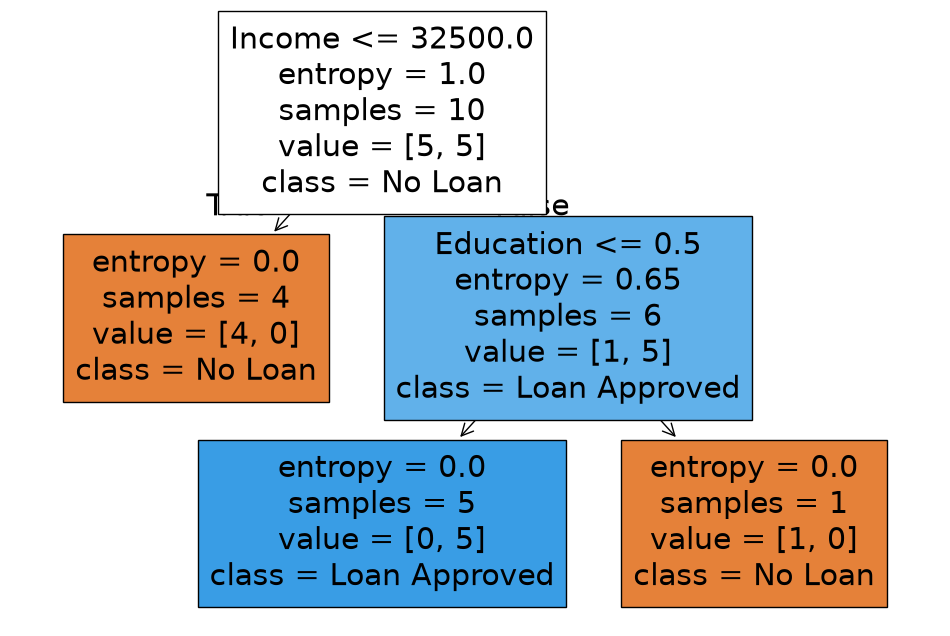

In [14]:
plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Loan", "Loan Approved"],
    filled=True
)

plt.show()

In [15]:
new_customer = [[1, 1, 0, 40000, 1]]

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


c:\Users\Shivam Mishra\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [20]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]


df = pd.read_csv(
    url,
    names=columns,
    na_values=" ?"
)


df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [21]:
print(df.shape)

(32561, 15)


In [22]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [23]:
df.dropna(inplace=True)

In [24]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='str')


C:\Users\Shivam Mishra\AppData\Local\Temp\ipykernel_4820\3603927628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [25]:
encoder = LabelEncoder()


for col in categorical_columns:
    df[col] = encoder.fit_transform(
        df[col]
    )

In [26]:
X = df.drop(
    "income",
    axis=1
)


y = df["income"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print(X_train.shape)
print(X_test.shape)

(24129, 14)
(6033, 14)


In [29]:
rf = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

In [30]:
rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [31]:
y_pred = rf.predict(
    X_test
)

In [32]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.863583623404608


In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)


print(cm)

[[4251  252]
 [ 571  959]]


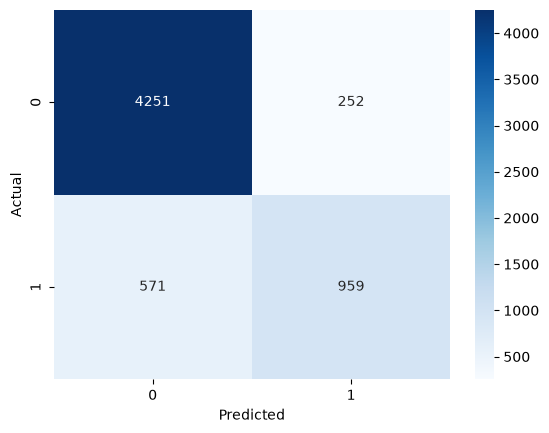

In [34]:
import seaborn as sns


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4503
           1       0.79      0.63      0.70      1530

    accuracy                           0.86      6033
   macro avg       0.84      0.79      0.81      6033
weighted avg       0.86      0.86      0.86      6033



In [36]:
importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": rf.feature_importances_
    }
)


importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
10,capital_gain,0.180095
7,relationship,0.173128
4,education_num,0.131808
5,marital_status,0.107325
0,age,0.098006
12,hours_per_week,0.062487
2,fnlwgt,0.054278
11,capital_loss,0.047666
6,occupation,0.046560
3,education,0.038204


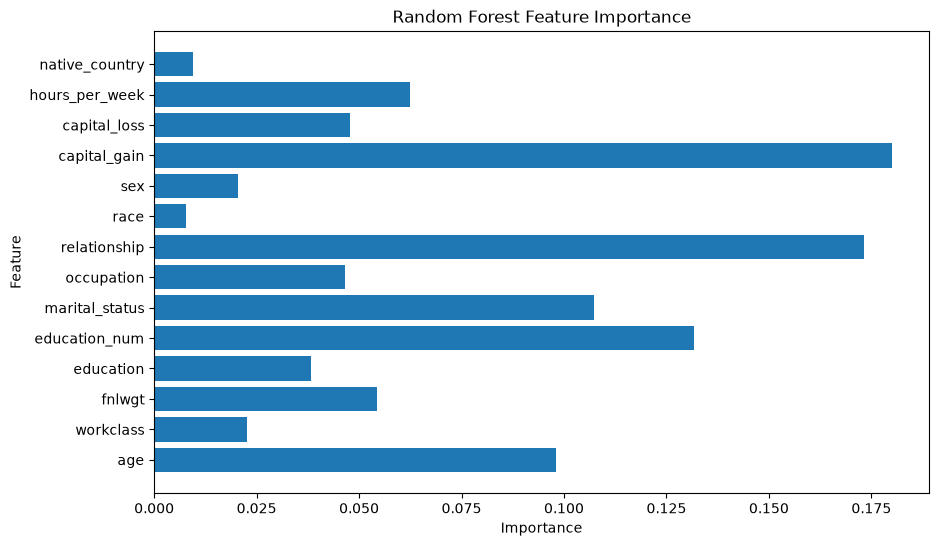

In [37]:
plt.figure(figsize=(10,6))


plt.barh(
    importance["Feature"],
    importance["Importance"]
)


plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)


plt.title(
    "Random Forest Feature Importance"
)


plt.show()

In [38]:
import joblib


joblib.dump(
    rf,
    "random_forest_income_model.pkl"
)

['random_forest_income_model.pkl']

In [39]:
model = joblib.load(
    "random_forest_income_model.pkl"
)


prediction = model.predict(
    X_test
)

print(prediction)

[0 0 0 ... 1 0 0]


In [40]:
RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    n_jobs=-1,
    max_features="sqrt",
    bootstrap=True
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether boots